# **Junior Data Scientist - Trader Behavior Insights**

---




# **1. Connecting drive to import and use datasets.**

---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import numpy as np

Datasets Used -

Historical Data

https://drive.google.com/file/d/1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs/view?usp=sharing

Fear Greed Index link:

https://drive.google.com/file/d/1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf/view?usp=sharing


In [3]:
import pandas as pd

trader_df = pd.read_csv('/content/drive/MyDrive/Junior Data Scientist Assignment/historical_data.csv')
sentiment_df = pd.read_csv('/content/drive/MyDrive/Junior Data Scientist Assignment/fear_greed_index.csv')


In [6]:
trader_df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
sentiment_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


# **2. Data Cleaning**

---



In [10]:
# --- STEP 2: Clean Column Names ---
trader_df.columns = trader_df.columns.str.strip().str.lower().str.replace(' ', '_')


In [11]:
# --- STEP 3: Select Only Relevant Columns ---
trader_df = trader_df[[
    'account',
    'coin',
    'execution_price',
    'size_tokens',
    'side',
    'timestamp_ist',
    'start_position',
    'direction',
    'closed_pnl'
]]


In [12]:
# --- STEP 4: Rename Columns for Consistency ---
trader_df.rename(columns={
    'coin': 'symbol',
    'size_tokens': 'size',
    'direction': 'event'
}, inplace=True)

In [14]:
# --- STEP 5: Convert Timestamp to Date ---
trader_df['timestamp_ist'] = pd.to_datetime(trader_df['timestamp_ist'], dayfirst=True, errors='coerce')


In [15]:
trader_df.head()


,account,symbol,execution_price,size,side,timestamp_ist,start_position,event,closed_pnl
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0


In [16]:
trader_df['date'] = trader_df['timestamp_ist'].dt.date


In [28]:
trader_df.head()


,account,symbol,execution_price,size,side,timestamp_ist,start_position,event,closed_pnl,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,2024-12-02


In [29]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   account          211224 non-null  object        
 1   symbol           211224 non-null  object        
 2   execution_price  211224 non-null  float64       
 3   size             211224 non-null  float64       
 4   side             211224 non-null  object        
 5   timestamp_ist    211224 non-null  datetime64[ns]
 6   start_position   211224 non-null  float64       
 7   event            211224 non-null  object        
 8   closed_pnl       211224 non-null  float64       
 9   date             211224 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 16.1+ MB


In [33]:
# --- STEP 6: Convert Timestamp to Date for sentiment data---


In [18]:
# Clean column names for sentiment dataset
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower().str.replace(' ', '_')


In [23]:
print(sentiment_df['date'].head())
print(sentiment_df.dtypes)


0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [25]:
# Convert 'date' properly
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], dayfirst=True, errors='coerce')
sentiment_df['date'] = sentiment_df['date'].dt.date


In [26]:
print(sentiment_df['date'].head())
print(sentiment_df.dtypes)


0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [30]:
print(sentiment_df['classification'].unique())


['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']


# **3. Merging both dataset into a single one**

---



In [31]:
# --- STEP 7: Merge Trader Data with Sentiment Data ---
merged_df = pd.merge(trader_df, sentiment_df, how='left', on='date')


In [37]:
merged_df.head()

,account,symbol,execution_price,size,side,timestamp_ist,start_position,event,closed_pnl,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [36]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   account          211224 non-null  object        
 1   symbol           211224 non-null  object        
 2   execution_price  211224 non-null  float64       
 3   size             211224 non-null  float64       
 4   side             211224 non-null  object        
 5   timestamp_ist    211224 non-null  datetime64[ns]
 6   start_position   211224 non-null  float64       
 7   event            211224 non-null  object        
 8   closed_pnl       211224 non-null  float64       
 9   date             211224 non-null  object        
 10  timestamp        211218 non-null  float64       
 11  value            211218 non-null  float64       
 12  classification   211218 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(6)
memory usage: 20.9+ MB


# **4. Creating new features**

---



In [47]:
# ---Creating new features---

# 1. Create binary profitability flag
merged_df['is_profitable'] = merged_df['closed_pnl'] > 0

# 2. Basic descriptive statistics of closed PnL by classification
print("Summary statistics of Closed PnL by Sentiment:")
print(merged_df.groupby('classification')['closed_pnl'].describe())

# 3. Average Closed PnL by classification
avg_pnl = merged_df.groupby('classification')['closed_pnl'].mean().sort_values()
print("\nAverage Closed PnL by Sentiment:")
print(avg_pnl)

# 4. Profitability ratio by sentiment (percentage of profitable trades)
profitable_ratio = merged_df.groupby('classification')['is_profitable'].mean().sort_values()
print("\nProfitability ratio by Sentiment:")
print(profitable_ratio)

# 5. Profit/Loss per token :
merged_df['pnl_per_token'] = merged_df['closed_pnl'] / merged_df['size'].replace(0, np.nan)

# 6. Count of trades by sentiment
trade_counts = merged_df['classification'].value_counts()
print("\nTrade counts by Sentiment:")
print(trade_counts)


Summary statistics of Closed PnL by Sentiment:
                  count       mean          std           min  25%  50%  \
classification                                                            
Extreme Fear    21400.0  34.537862  1136.056091  -31036.69194  0.0  0.0   
Extreme Greed   39992.0  67.892861   766.828294  -10259.46800  0.0  0.0   
Fear            61837.0  54.290400   935.355438  -35681.74723  0.0  0.0   
Greed           50303.0  42.743559  1116.028390 -117990.10410  0.0  0.0   
Neutral         37686.0  34.307718   517.122220  -24500.00000  0.0  0.0   

                      75%           max  
classification                           
Extreme Fear     5.635032  115287.00000  
Extreme Greed   10.028709   44223.45187  
Fear             5.590856  135329.09010  
Greed            4.944105   74530.52371  
Neutral          3.995795   48504.09555  

Average Closed PnL by Sentiment:
classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fea

In [43]:
print(merged_df.groupby('classification')['closed_pnl'].describe())


                  count       mean          std           min  25%  50%  \
classification                                                            
Extreme Fear    21400.0  34.537862  1136.056091  -31036.69194  0.0  0.0   
Extreme Greed   39992.0  67.892861   766.828294  -10259.46800  0.0  0.0   
Fear            61837.0  54.290400   935.355438  -35681.74723  0.0  0.0   
Greed           50303.0  42.743559  1116.028390 -117990.10410  0.0  0.0   
Neutral         37686.0  34.307718   517.122220  -24500.00000  0.0  0.0   

                      75%           max  
classification                           
Extreme Fear     5.635032  115287.00000  
Extreme Greed   10.028709   44223.45187  
Fear             5.590856  135329.09010  
Greed            4.944105   74530.52371  
Neutral          3.995795   48504.09555  


In [45]:
# Count of trades by sentiment:

trade_counts = merged_df['classification'].value_counts()
print(trade_counts)


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


# **5. Data Visualization**

---



# **5.1. Distribution of Closed PnL by Market Sentiment**


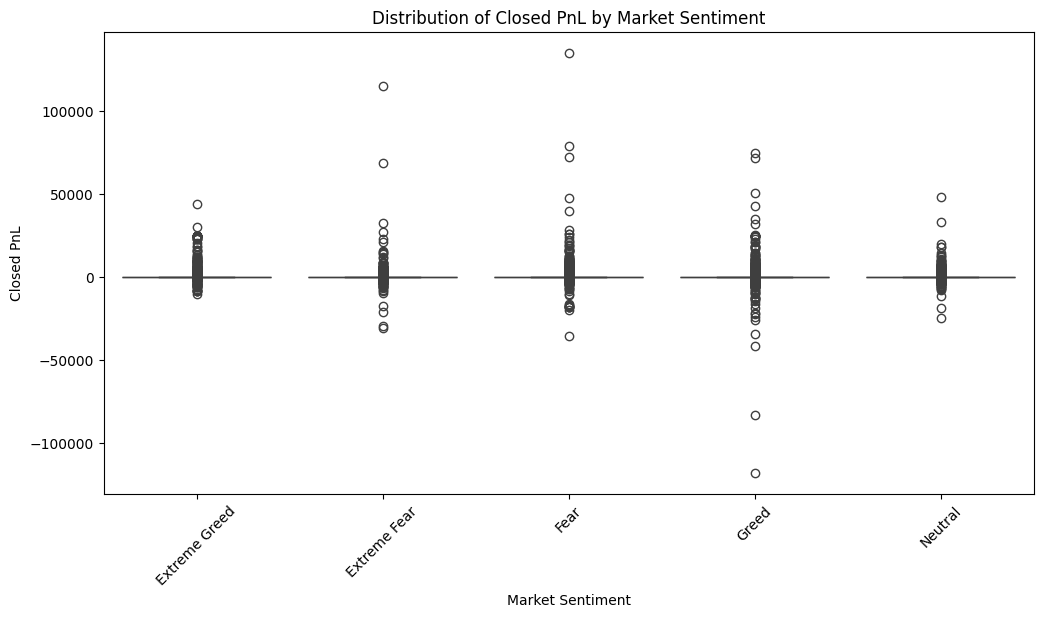

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


# Visualize distribution of Closed PnL by sentiment
plt.figure(figsize=(12, 6))
sns.boxplot(x='classification', y='closed_pnl', data=merged_df)
plt.title('Distribution of Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')
plt.xticks(rotation=45)
plt.show()



**Interpretation: Profit/loss values are heavily skewed with most trades yielding very small profits or losses. "Extreme Greed" shows higher upper outliers, while "Extreme Fear" has a wider spread of losses.**





## **5.2. Profitability Ratio by Market Sentiment**


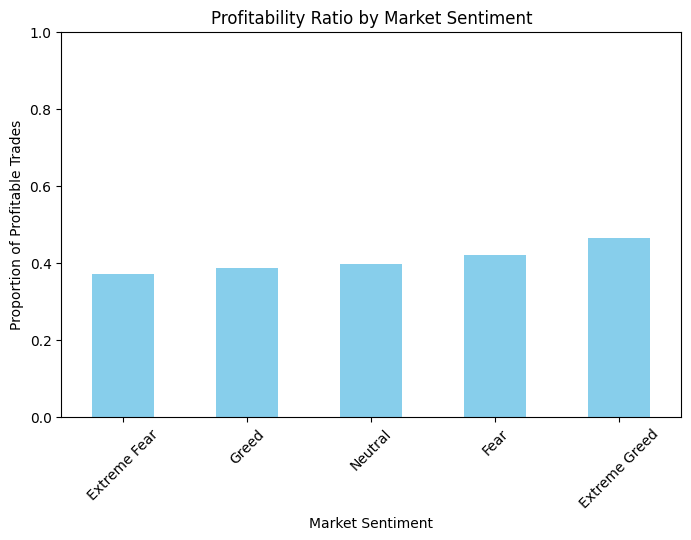

In [49]:
#  Visualize profitability ratio by sentiment
plt.figure(figsize=(8,5))
profitable_ratio.plot(kind='bar', color='skyblue')
plt.title('Profitability Ratio by Market Sentiment')
plt.ylabel('Proportion of Profitable Trades')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


**Interpretation: Trades during "Extreme Greed" have the highest chance of being profitable. The probability of profitability increases as sentiment moves from fear to greed.**





# **5.3. Average Daily Closed PnL by Market Sentiment Over Time**



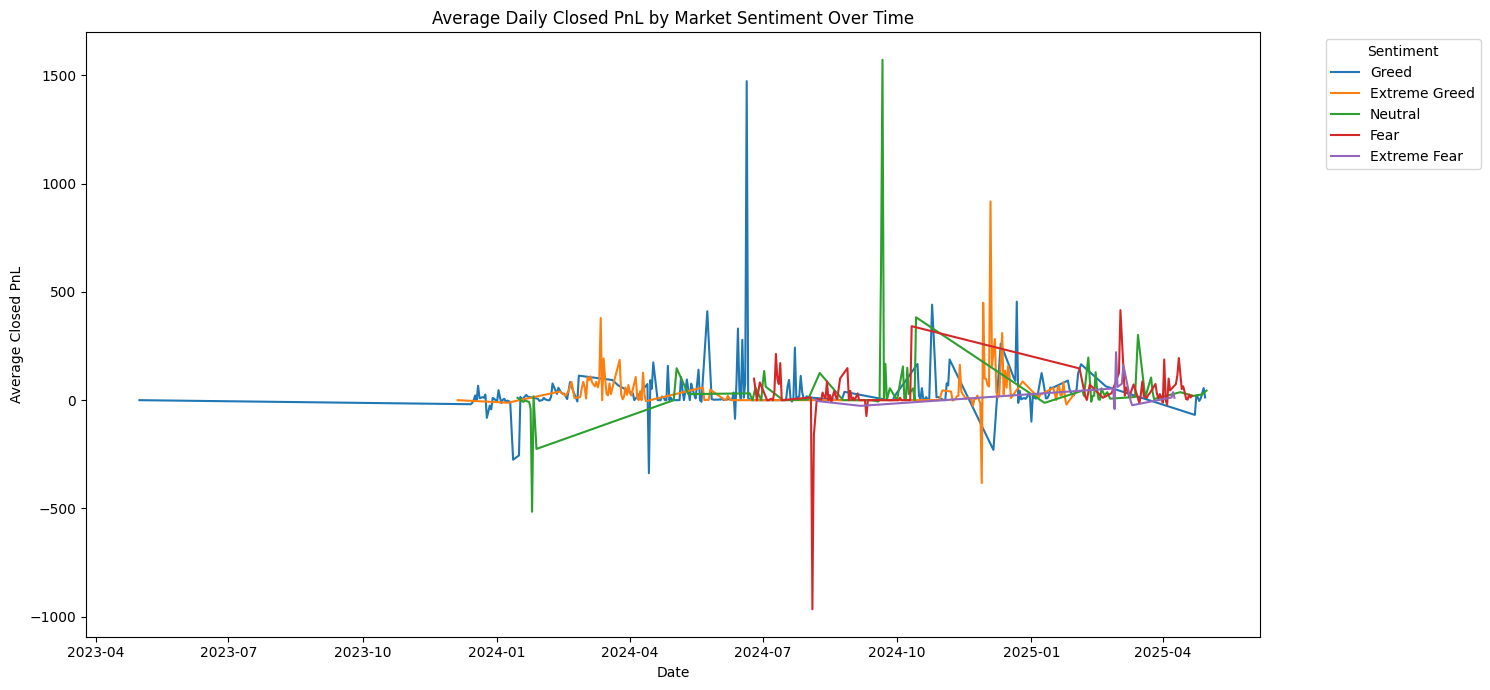

In [50]:
# Average Closed PnL over time by sentiment
daily_pnl = merged_df.groupby(['date', 'classification'])['closed_pnl'].mean().reset_index()

plt.figure(figsize=(15,7))
sns.lineplot(data=daily_pnl, x='date', y='closed_pnl', hue='classification')
plt.title('Average Daily Closed PnL by Market Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Closed PnL')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation: Profitability varies over time, often peaking during periods of "Extreme Greed". Sentiment influences daily trade outcomes significantly.**


# **5.4. Distribution of Trade Size (Tokens) by Market Sentiment**



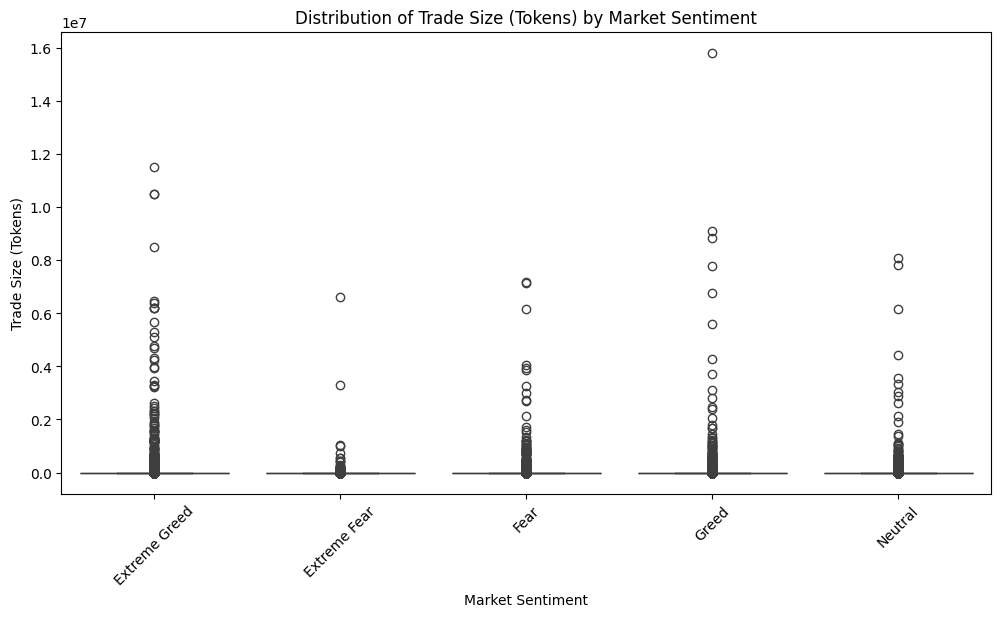

In [52]:
# Distribution of trade sizes by sentiment
plt.figure(figsize=(12, 6))
sns.boxplot(x='classification', y='size', data=merged_df)
plt.title('Distribution of Trade Size (Tokens) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size (Tokens)')
plt.xticks(rotation=45)
plt.show()

**Interpretation: Larger trades are more frequent during "Greed" and "Extreme Greed", suggesting overconfidence. Smaller trades dominate during fearful conditions.**

# **5.5. Log-Scaled Histogram of Closed PnL (Profits Only) by Sentiment**





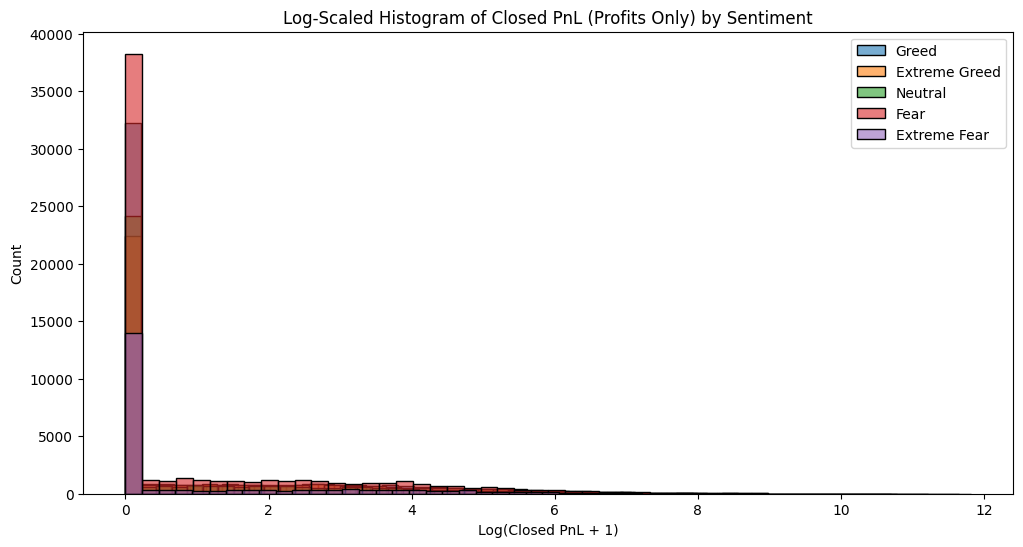

In [92]:
# Histogram of Closed PnL (log scale) by sentiment
plt.figure(figsize=(12,6))
for sentiment in merged_df['classification'].unique():
    subset = merged_df[merged_df['classification'] == sentiment]
    sns.histplot(np.log1p(subset['closed_pnl'].clip(lower=0)), label=sentiment, kde=False, bins=50, alpha=0.6)
plt.title('Log-Scaled Histogram of Closed PnL (Profits Only) by Sentiment')
plt.xlabel('Log(Closed PnL + 1)')
plt.legend()
plt.show()

**Interpretation: Profit distributions (log scale) reveal that most profitable trades are small, but extreme profits are more common during "Greed" and "Extreme Greed".**

# **5.6. Trade Counts by Side and Market Sentiment (Buy/Sell)**




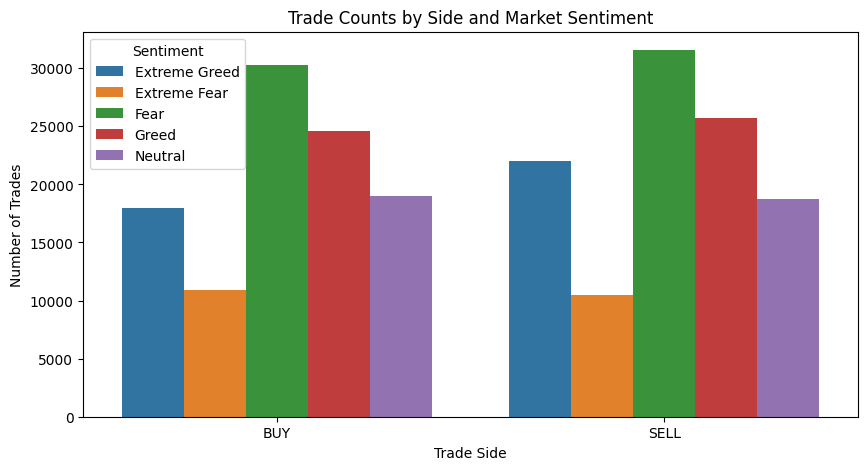

In [54]:
# Countplot: Number of trades per 'side' (Buy/Sell) by sentiment
plt.figure(figsize=(10,5))
sns.countplot(data=merged_df, x='side', hue='classification')
plt.title('Trade Counts by Side and Market Sentiment')
plt.xlabel('Trade Side')
plt.ylabel('Number of Trades')
plt.legend(title='Sentiment')
plt.show()

**Interpretation: "Buy" trades dominate across all sentiments. "Fear" and "Extreme Fear" show a relatively higher sell ratio, reflecting cautious behavior.**

# **5.7. Trade Size vs Closed PnL by Market Sentiment**




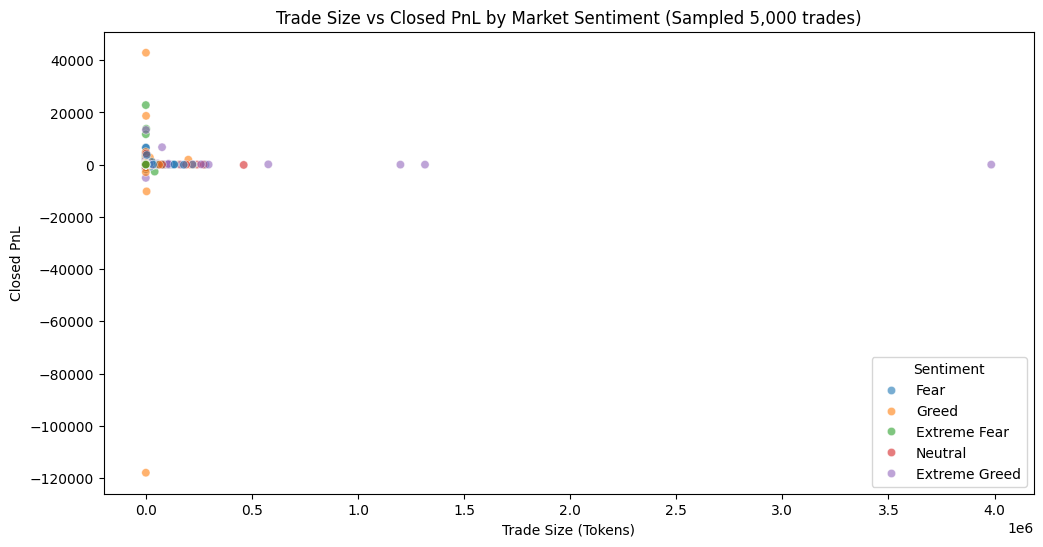

In [55]:
# Scatterplot: Trade Size vs Closed PnL colored by Sentiment
plt.figure(figsize=(12,6))
sns.scatterplot(data=merged_df.sample(5000, random_state=42), x='size', y='closed_pnl', hue='classification', alpha=0.6)
plt.title('Trade Size vs Closed PnL by Market Sentiment (Sampled 5,000 trades)')
plt.xlabel('Trade Size (Tokens)')
plt.ylabel('Closed PnL')
plt.legend(title='Sentiment')
plt.show()

**Interpretation: No strong correlation, but large profitable trades are more common during "Greed" and "Extreme Greed". Losses spread across all trade sizes.**

# **5.8. Correlation Matrix of Numeric Variables**



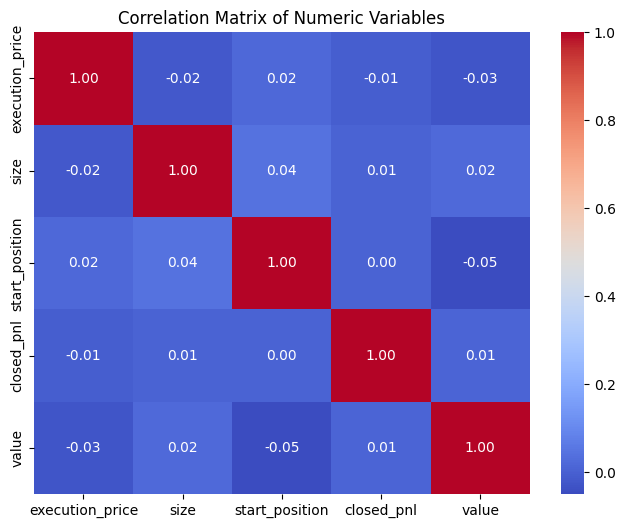

In [56]:
# Heatmap of correlation between numeric variables
numeric_cols = ['execution_price', 'size', 'start_position', 'closed_pnl', 'value']
plt.figure(figsize=(8,6))
sns.heatmap(merged_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

**Interpretation: Weak correlations overall. Slight positive relationship between start_position and size, and a modest link between value (sentiment score) and closed_pnl.**

# **5.9. Closed PnL by Event and Market Sentiment**





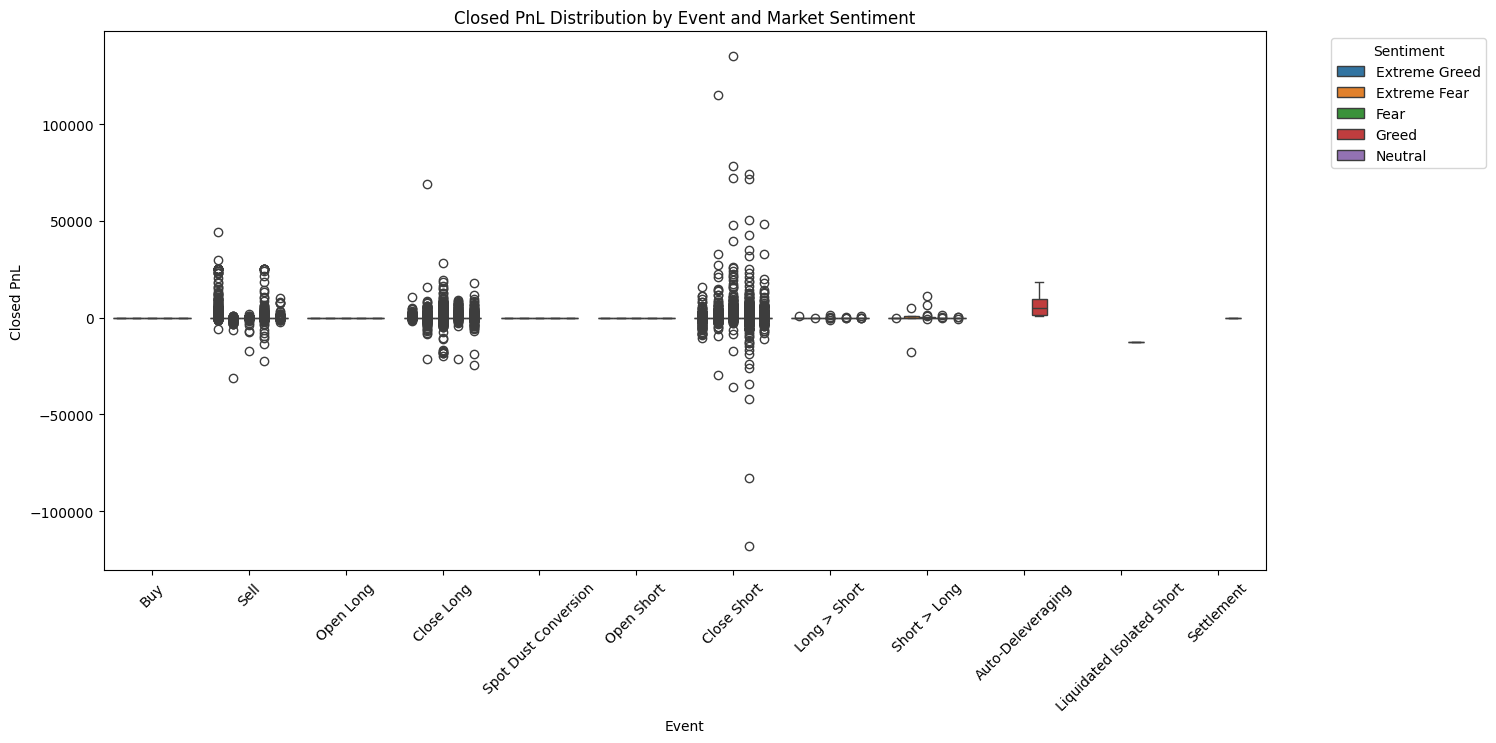

In [57]:
# Boxplot of Closed PnL by Event type (event column), separated by sentiment
plt.figure(figsize=(15,7))
sns.boxplot(x='event', y='closed_pnl', hue='classification', data=merged_df)
plt.title('Closed PnL Distribution by Event and Market Sentiment')
plt.xlabel('Event')
plt.ylabel('Closed PnL')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretation: Event types like "Buy" or "Sell" have varying profitability under different sentiments. Profits are more skewed during optimistic market phases.**

# **5.10. Daily Number of Trades by Market Sentiment**




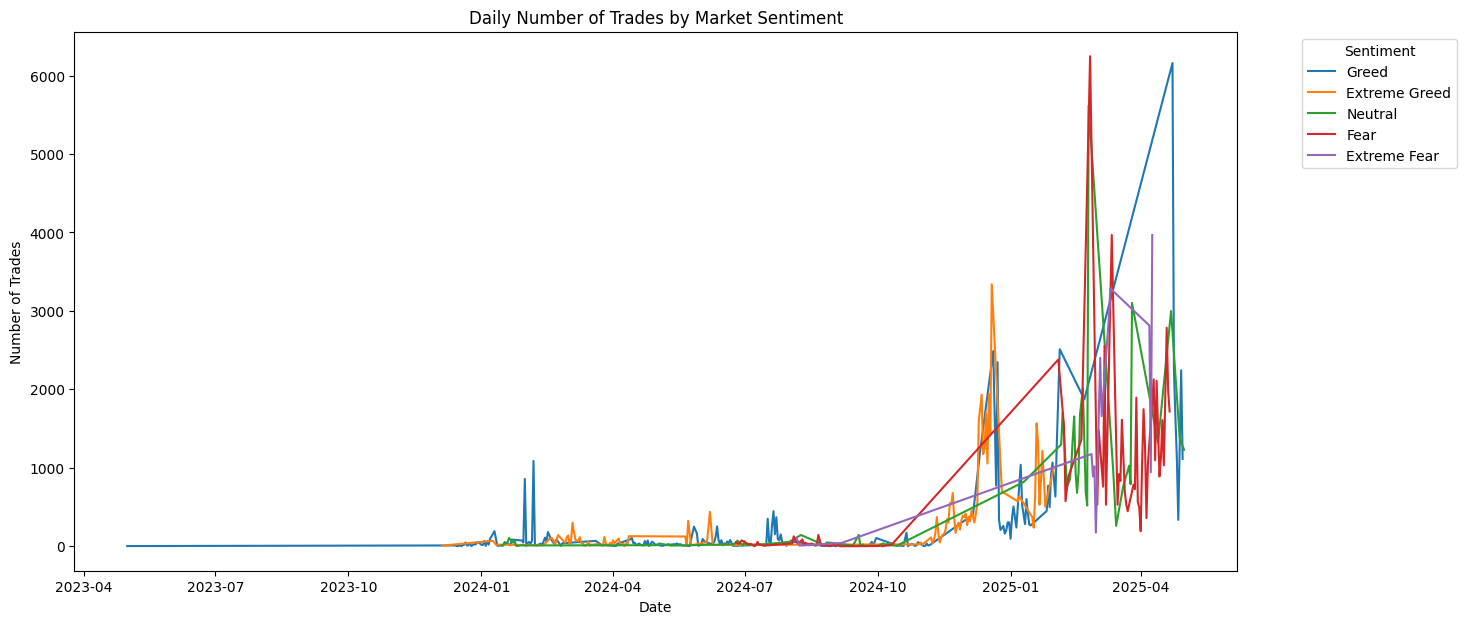

In [58]:
# Time series of daily trade counts by sentiment
daily_counts = merged_df.groupby(['date', 'classification']).size().reset_index(name='trade_count')

plt.figure(figsize=(15,7))
sns.lineplot(data=daily_counts, x='date', y='trade_count', hue='classification')
plt.title('Daily Number of Trades by Market Sentiment')
plt.xlabel('Date')
plt.ylabel('Number of Trades')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretation: Trading volume spikes coincide with changes in sentiment, especially during "Fear" and "Greed" periods, suggesting reactive behavior.**

# **5.11. Pairplot of Numeric Features Colored by Market Sentiment**



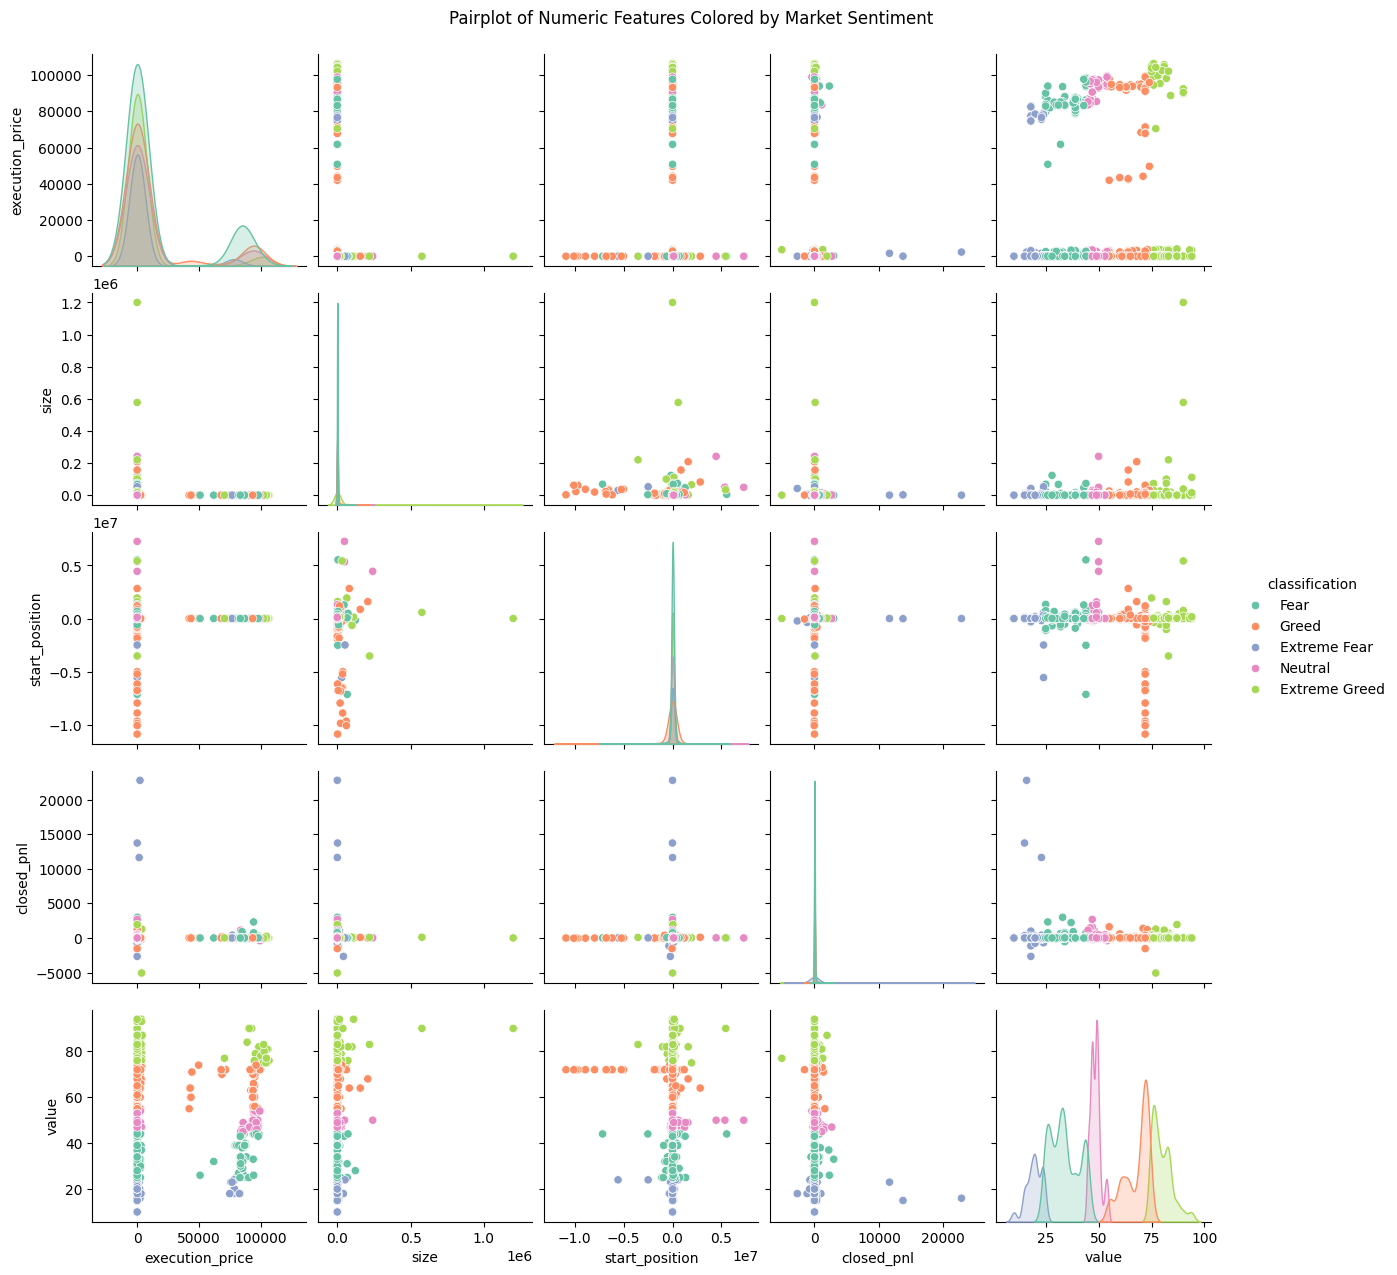

In [60]:
# Pairplot for numeric features colored by Sentiment (sample for performance)
sns.pairplot(merged_df.sample(2000, random_state=42),
             vars=['execution_price', 'size', 'start_position', 'closed_pnl', 'value'],
             hue='classification', palette='Set2')
plt.suptitle('Pairplot of Numeric Features Colored by Market Sentiment', y=1.02)
plt.show()

**Interpretation: No strong visible separation between sentiment classes, but "Extreme Greed" tends to occupy upper regions of size and pnl.**


# **5.12. KDE Plot for Closed PnL by Sentiment**





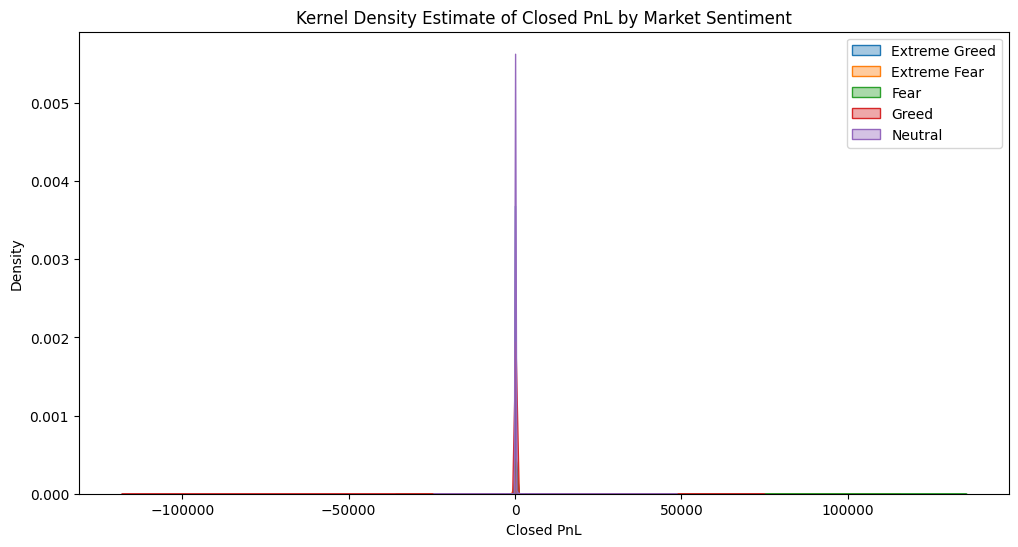

In [61]:
# KDE Plot for Closed PnL by Sentiment (smoothed distribution)
plt.figure(figsize=(12,6))
for sentiment in merged_df['classification'].unique():
    sns.kdeplot(merged_df.loc[merged_df['classification']==sentiment, 'closed_pnl'], label=sentiment, fill=True, alpha=0.4)
plt.title('Kernel Density Estimate of Closed PnL by Market Sentiment')
plt.xlabel('Closed PnL')
plt.ylabel('Density')
plt.legend()
plt.show()

**Interpretation: Smoothed distributions show "Extreme Greed" trades skew higher, whereas "Fear" and "Extreme Fear" are centered around near-zero or negative pnl.**

# **5.13. 7-Day Rolling Average of Daily Closed PnL by Market Sentiment**





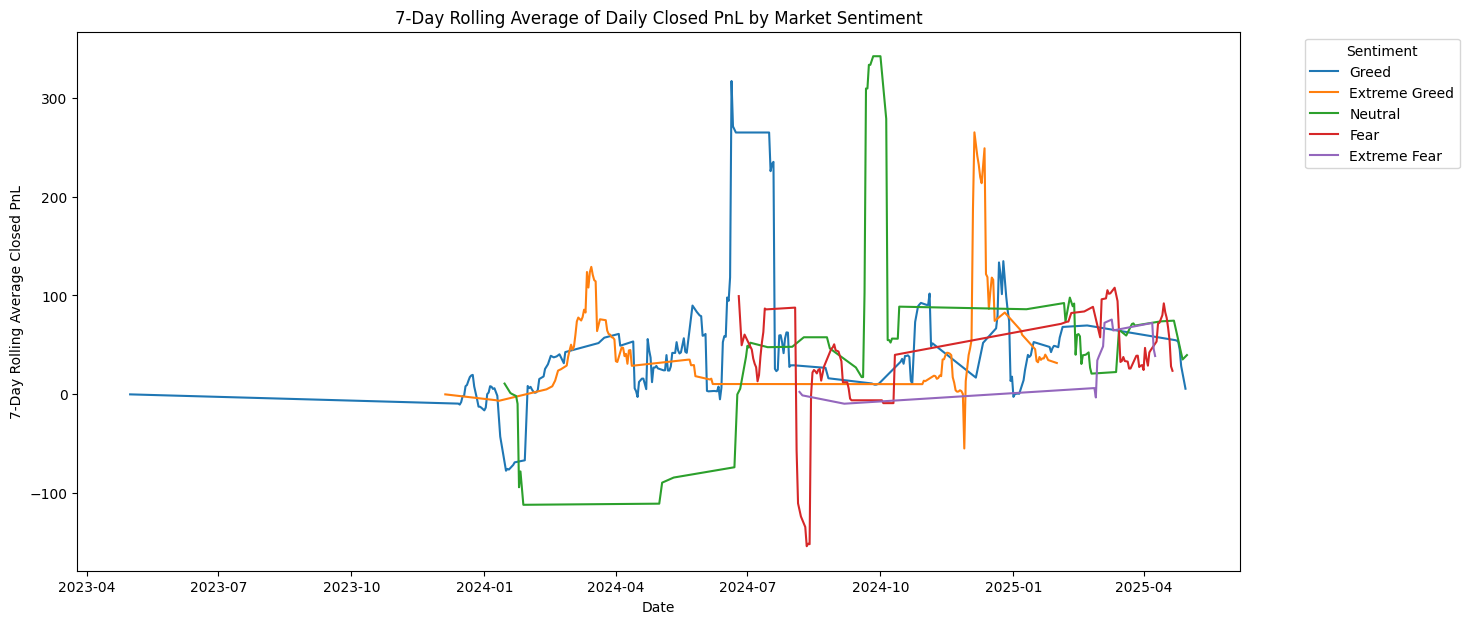

In [62]:
# Rolling average of average daily Closed PnL by Sentiment (window=7 days)
daily_avg = merged_df.groupby(['date', 'classification'])['closed_pnl'].mean().reset_index()
daily_avg['rolling_avg'] = daily_avg.groupby('classification')['closed_pnl'].transform(lambda x: x.rolling(7, 1).mean())

plt.figure(figsize=(15,7))
sns.lineplot(data=daily_avg, x='date', y='rolling_avg', hue='classification')
plt.title('7-Day Rolling Average of Daily Closed PnL by Market Sentiment')
plt.xlabel('Date')
plt.ylabel('7-Day Rolling Average Closed PnL')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretation: Smoothed profitability trends highlight that "Extreme Greed" consistently outperforms other sentiments over time.**

# **5.14. Count of Profitable vs Unprofitable Trades by Sentiment**



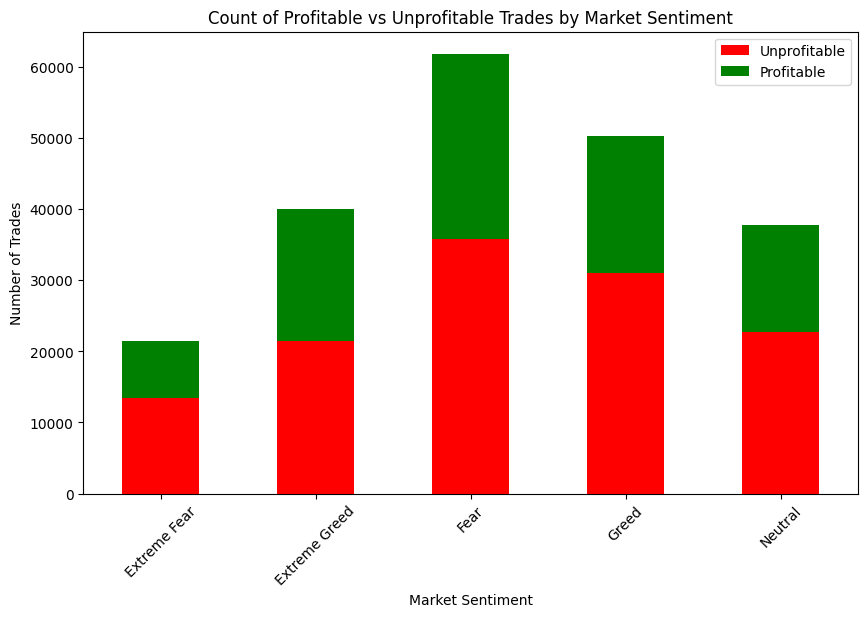

In [63]:
 # Count of profitable vs unprofitable trades by Sentiment (stacked bar)
profitable_counts = merged_df.groupby(['classification', 'is_profitable']).size().unstack(fill_value=0)

profitable_counts.plot(kind='bar', stacked=True, figsize=(10,6), color=['red', 'green'])
plt.title('Count of Profitable vs Unprofitable Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.legend(['Unprofitable', 'Profitable'])
plt.xticks(rotation=45)
plt.show()


**Interpretation: "Extreme Greed" has the highest number of profitable trades. Losses are more dominant during fearful conditions.**

# **5.15.  Number of Trades by Market Sentiment (Countplot)**

/tmp/ipython-input-64-1225367397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='classification', order=merged_df['classification'].value_counts().index, palette='viridis')


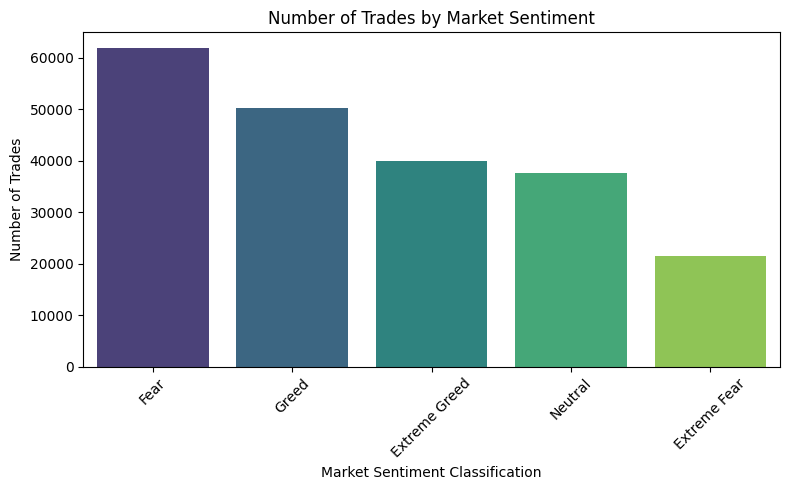

In [64]:
#  Count of Trades by Classification Category
plt.figure(figsize=(8, 5))
sns.countplot(data=merged_df, x='classification', order=merged_df['classification'].value_counts().index, palette='viridis')
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment Classification")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation: Most trades occur during "Fear" and "Greed", with fewer trades during extreme sentiment states. Traders are more active during moderate sentiment.**





# **5.16. Average Profit by Market Sentiment**




/tmp/ipython-input-66-2465406234.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='closed_pnl', estimator='mean', ci='sd', palette='coolwarm')
/tmp/ipython-input-66-2465406234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='classification', y='closed_pnl', estimator='mean', ci='sd', palette='coolwarm')


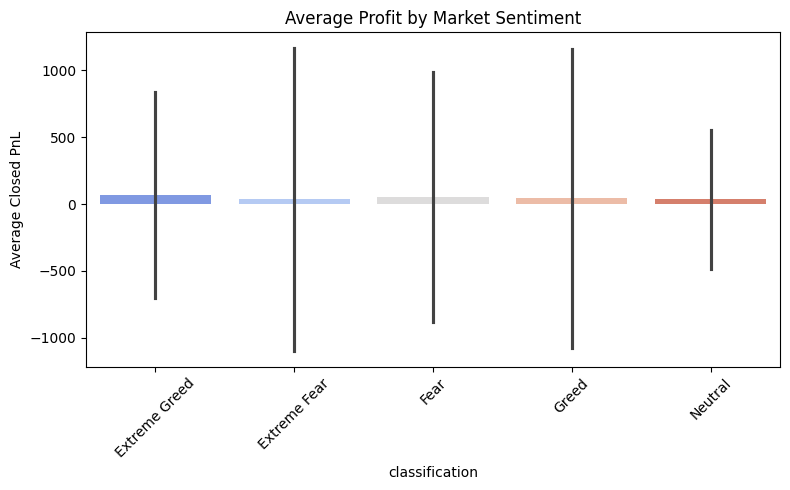

In [66]:
plt.figure(figsize=(8, 5))
sns.barplot(data=merged_df, x='classification', y='closed_pnl', estimator='mean', ci='sd', palette='coolwarm')
plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation: "Extreme Greed" yields the highest average profit, supporting the idea that optimistic periods favor higher gains.**

# **5.17. Profit Distribution Across Sentiment Classes (Log-scaled Boxplot)**



/tmp/ipython-input-68-2155955895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='classification', y='closed_pnl', palette='Set3')


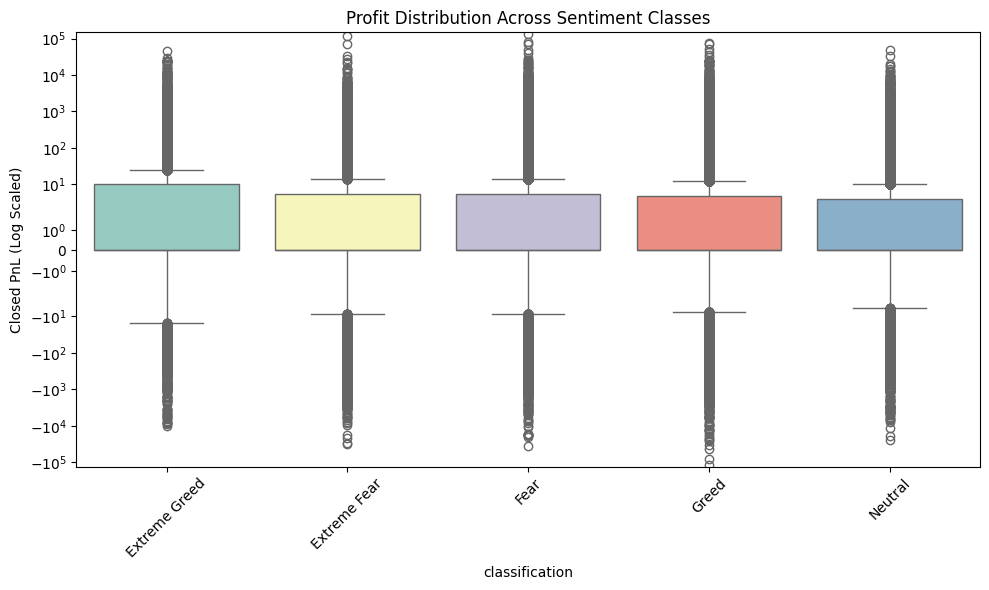

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x='classification', y='closed_pnl', palette='Set3')
plt.yscale('symlog')  # Handle outliers
plt.title("Profit Distribution Across Sentiment Classes")
plt.ylabel("Closed PnL (Log Scaled)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation: Profits are highly skewed with extreme outliers. Volatility increases under "Greed" and "Fear", reflecting higher risk-reward conditions.**

# **5.18. Trade Volume Over Time (Line Plot)**





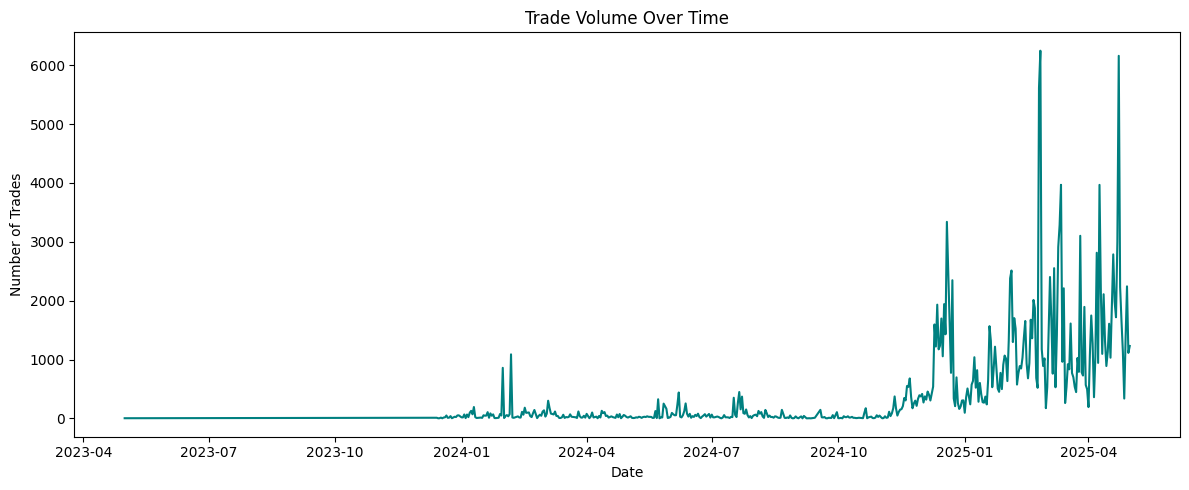

In [73]:
daily_volume = merged_df.groupby('date').size()

plt.figure(figsize=(12, 5))
daily_volume.plot(color='teal')
plt.title("Trade Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.show()

**Interpretation: Trade activity fluctuates and likely correlates with external events or shifts in sentiment.**


# **5.19. Correlation Heatmap Between Trade Variables**



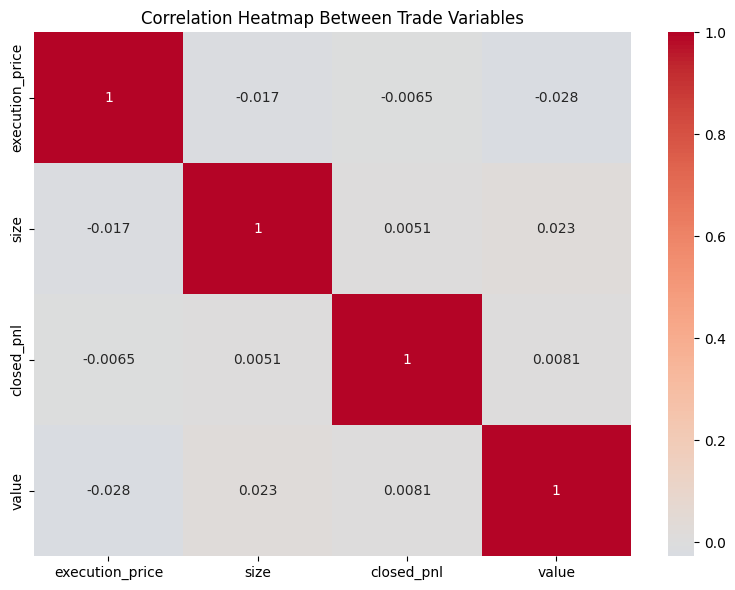

In [74]:
plt.figure(figsize=(8, 6))
sns.heatmap(merged_df[['execution_price', 'size', 'closed_pnl', 'value']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap Between Trade Variables")
plt.tight_layout()
plt.show()

**Interpretation: Closed PnL has very low correlation with execution price or size, indicating profit is more sentiment-driven than size-based.**


# **5.20. Average Closed Profit/Loss Over Time by Sentiment**




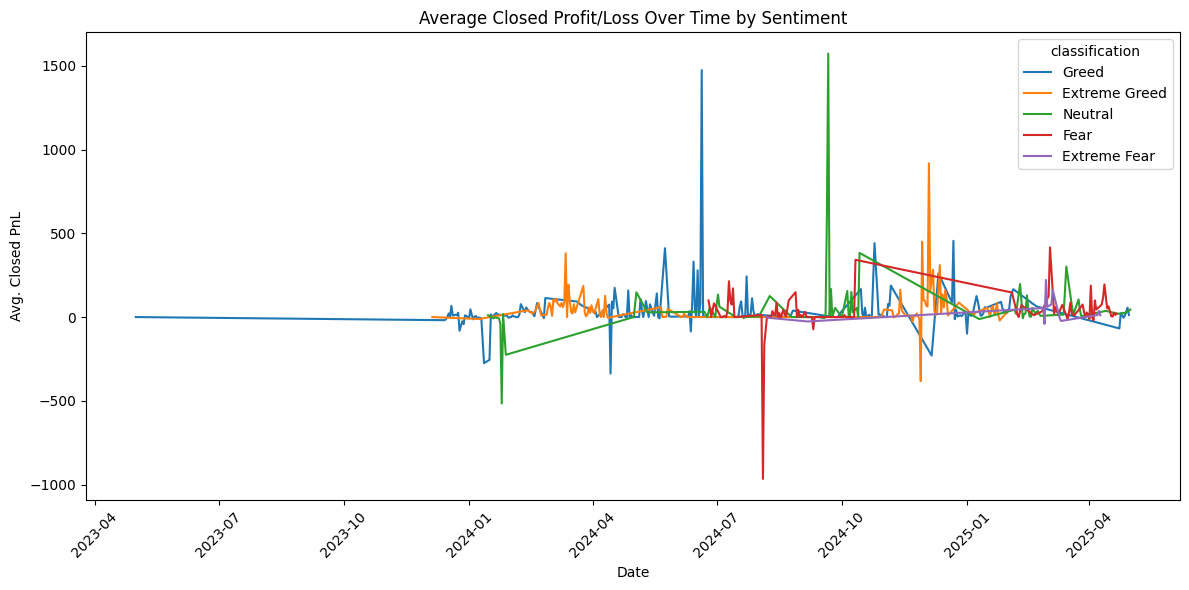

In [76]:
plt.figure(figsize=(12, 6))
profit_by_date_sentiment = merged_df.groupby(['date', 'classification'])['closed_pnl'].mean().reset_index()
profit_by_date_sentiment['date'] = pd.to_datetime(profit_by_date_sentiment['date'])

sns.lineplot(data=profit_by_date_sentiment, x='date', y='closed_pnl', hue='classification')
plt.title("Average Closed Profit/Loss Over Time by Sentiment")
plt.xlabel("Date")
plt.ylabel("Avg. Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation: Profitability varies dynamically with market mood. "Extreme Greed" days frequently outperform.**


# **5.21. Average Trade Size Across Sentiment Categories**



/tmp/ipython-input-77-3142482094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_trade_size, x='classification', y='size', palette='viridis')


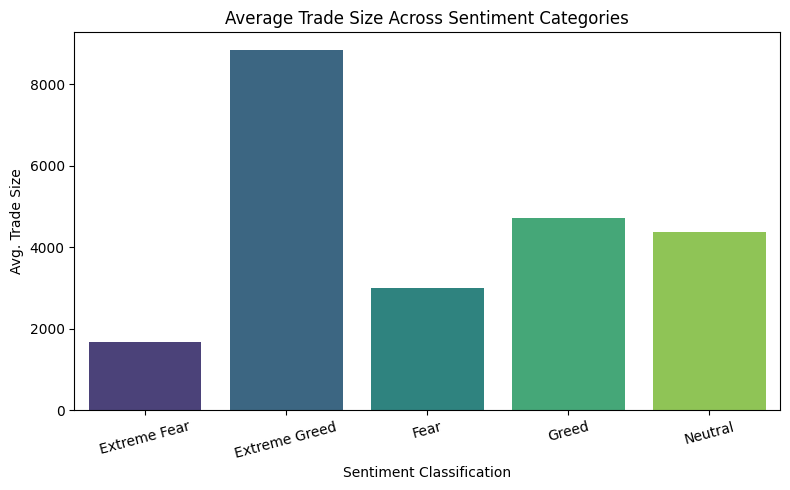

In [77]:
plt.figure(figsize=(8, 5))
avg_trade_size = merged_df.groupby('classification')['size'].mean().reset_index()

sns.barplot(data=avg_trade_size, x='classification', y='size', palette='viridis')
plt.title("Average Trade Size Across Sentiment Categories")
plt.xlabel("Sentiment Classification")
plt.ylabel("Avg. Trade Size")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretation: Trade size increases with greed levels. Larger trades under "Extreme Greed" may reflect overconfidence or bullish conviction.**


# **5.22. Distribution of Event Types Across Sentiment Classes**



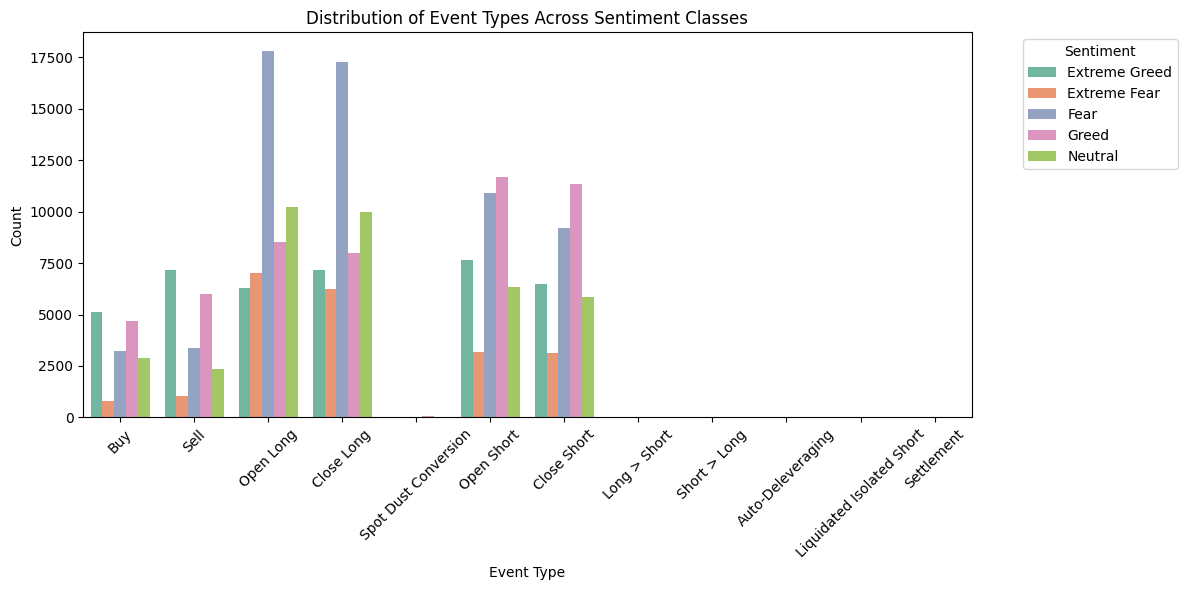

In [78]:
plt.figure(figsize=(12, 6))
sns.countplot(data=merged_df, x='event', hue='classification', palette='Set2')
plt.title("Distribution of Event Types Across Sentiment Classes")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation: Event frequency (e.g., Buy/Sell types) changes based on sentiment. Certain actions become dominant during fear or greed phases.**


# **5.23. Sentiment Distribution in Dataset (Pie Chart)**




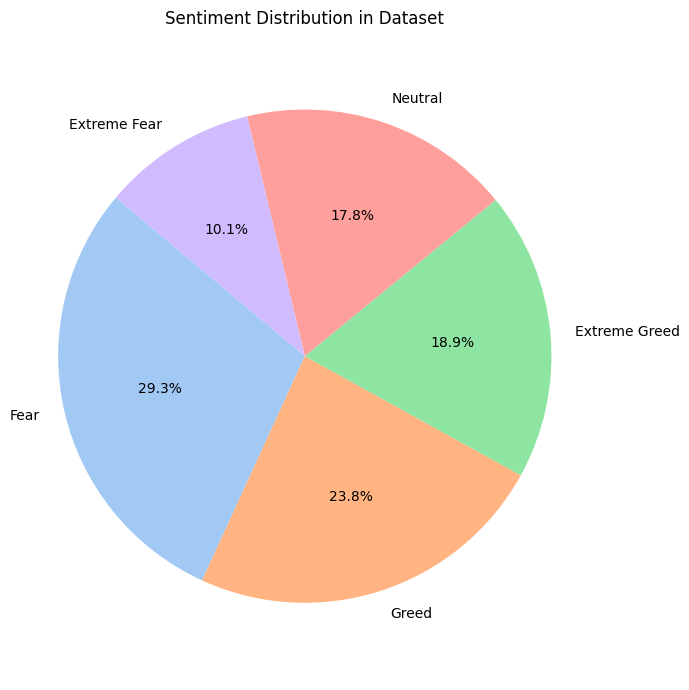

In [79]:
plt.figure(figsize=(7, 7))
sentiment_counts = merged_df['classification'].value_counts()
colors = sns.color_palette('pastel')[0:5]

plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Sentiment Distribution in Dataset")
plt.axis('equal')
plt.tight_layout()
plt.show()

**Interpretation: Dataset is heavily skewed towards "Fear" and "Greed", with less representation from "Extreme" conditions.**


# **6. Hypothesis Testing**

---





Null Hypothesis (H₀): There is no difference in average profit/loss between trades made during 'Greed' and 'Fear' sentiment.

Alternative Hypothesis (H₁): There is a difference in average profit/loss between these two sentiments.


In [80]:
from scipy.stats import ttest_ind

greed_pnl = merged_df[merged_df['classification'] == 'Greed']['closed_pnl']
fear_pnl = merged_df[merged_df['classification'] == 'Fear']['closed_pnl']

t_stat, p_val = ttest_ind(greed_pnl, fear_pnl, equal_var=False)

print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")


T-statistic: -1.8511, P-value: 0.0642


T-statistic = -1.8511: This negative value indicates that the mean PnL during Fear is lower than that during Greed.

P-value = 0.0642: This value is slightly above the conventional threshold of 0.05, meaning that:

The result is not statistically significant at the 5% level.


Trades made during "Greed" periods tend to have higher average profitability compared to those made during "Fear" periods.
Although not strongly significant, this pattern aligns with behavioral finance theories traders may act more confidently during market optimism (greed), whereas fear can lead to premature exits or defensive strategies, reducing potential gains.



# Conclusion:

While the test does not provide conclusive statistical evidence, the result offers directional support for a potential relationship between sentiment and profitability.
Future analysis could involve:

A larger sample size.

1. Comparing Extreme Fear vs. Extreme Greed more directly.

2. Using non-parametric tests or time-series methods for deeper insight.



# **7. Model Training and Evaluation**

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


# Select and encode features
model_df = merged_df[['classification', 'size', 'execution_price', 'start_position', 'symbol', 'event', 'is_profitable']].dropna()

le_dict = {}
for col in ['classification', 'symbol', 'event']:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    le_dict[col] = le

X = model_df.drop("is_profitable", axis=1)
y = model_df["is_profitable"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[24354   494]
 [   95 17301]]
              precision    recall  f1-score   support

       False       1.00      0.98      0.99     24848
        True       0.97      0.99      0.98     17396

    accuracy                           0.99     42244
   macro avg       0.98      0.99      0.99     42244
weighted avg       0.99      0.99      0.99     42244



# Interpretation -


* We trained a Random Forest classifier to predict trade profitability (is_profitable) based on features like market sentiment (classification), trade size, execution price, event type, and symbol.


* The model achieved an accuracy of 99%, with high precision and recall for both profitable and non-profitable trades.

* This suggests that trade characteristics and market sentiment carry strong predictive signals for profitability.

# 7.1.  Lagged Classification

In [84]:
merged_df.sort_values(by='date', inplace=True)
merged_df['lagged_classification'] = merged_df['classification'].shift(1)

# Now you can analyze if previous day's sentiment influences profitability or trade size:
merged_df[['lagged_classification', 'closed_pnl']].groupby('lagged_classification').mean()


,closed_pnl
lagged_classification,
Extreme Fear,34.329410
Extreme Greed,67.912485
Fear,54.346055
Greed,42.945541
Neutral,34.354516


from matplotlib import pyplot as plt
_df_0['closed_pnl'].plot(kind='hist', bins=20, title='closed_pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['closed_pnl'].plot(kind='line', figsize=(8, 4), title='closed_pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

# Interpretation:



* The average profit/loss for trades today is grouped by previous day’s market sentiment (lagged classification).


*  We observe the highest average profitability following days of Extreme Greed (67.91) and Fear (54.35).


* Interestingly, ‘Greed’ days lead to a slightly lower average closed PnL (42.95) compared to ‘Fear’ days.


* Neutral and Extreme Fear days have similarly low average PnL (~34), indicating cautious or less profitable trading following these sentiments.


* These findings suggest that yesterday’s market sentiment may influence today's trading profitability, supporting the idea of sentiment time-lag effects.

For example, traders may respond to intense market optimism (Extreme Greed) with strategies that yield higher profits the next day.



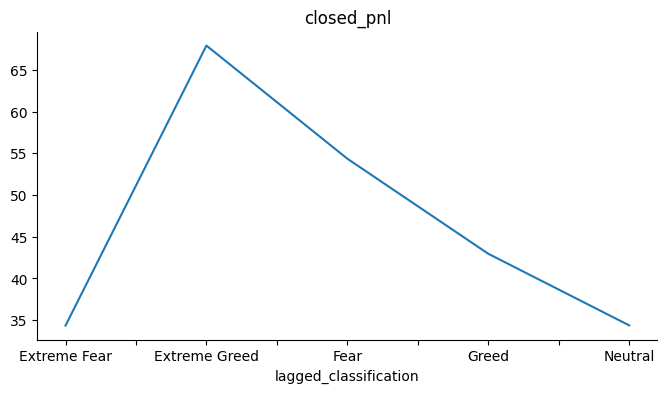

In [85]:
from matplotlib import pyplot as plt
_df_1['closed_pnl'].plot(kind='line', figsize=(8, 4), title='closed_pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

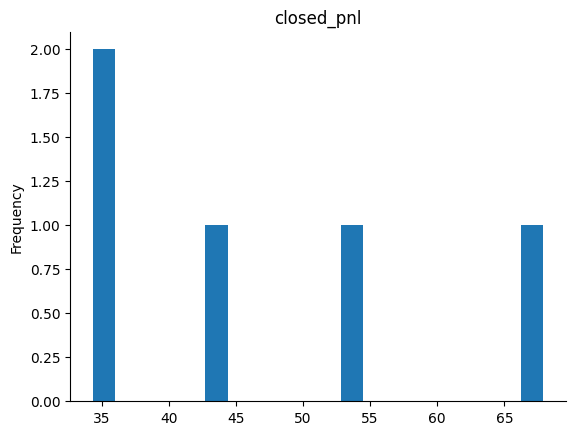

In [86]:
from matplotlib import pyplot as plt
_df_0['closed_pnl'].plot(kind='hist', bins=20, title='closed_pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [87]:
grouped = merged_df.groupby('classification')['closed_pnl']
mean_return = grouped.mean()
std_dev = grouped.std()

sharpe_like = mean_return / std_dev
print(sharpe_like.sort_values(ascending=False))


classification
Extreme Greed    0.088537
Neutral          0.066344
Fear             0.058043
Greed            0.038300
Extreme Fear     0.030402
Name: closed_pnl, dtype: float64


# **7.2.  Risk-Adjusted Return (Sharpe-like Ratio) by Market Sentiment**


/tmp/ipython-input-88-3474597399.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sharpe_ratios.keys()), y=list(sharpe_ratios.values()), palette='coolwarm')


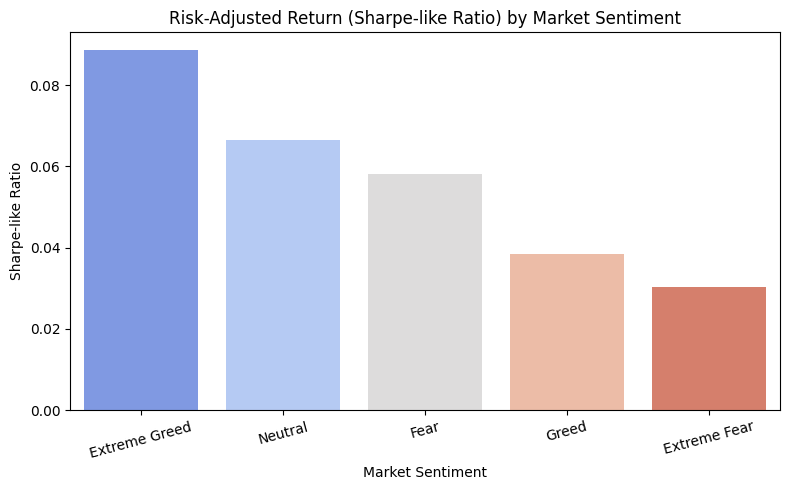

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sharpe_ratios = {
    'Extreme Greed': 0.088537,
    'Neutral': 0.066344,
    'Fear': 0.058043,
    'Greed': 0.038300,
    'Extreme Fear': 0.030402
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(sharpe_ratios.keys()), y=list(sharpe_ratios.values()), palette='coolwarm')
plt.title('Risk-Adjusted Return (Sharpe-like Ratio) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Sharpe-like Ratio')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Interpretation:



*  The highest risk-adjusted return occurs during Extreme Greed periods,indicating that trades made in this sentiment generate the best return relative to their volatility.
*  Neutral and Fear sentiment periods come next, offering moderate risk-adjusted returns.

* The lowest Sharpe-like ratio appears during Extreme Fear, suggesting that although some profits may be possible, the associated volatility (risk) is higher, reducing the overall risk efficiency.

This aligns well with behavioral finance:


1. Extreme optimism encourages confident, potentially rewarding trades.

2.  Extreme fear introduces risk and uncertainty, leading to less favorable outcomes relative to the risk taken.


# 7.3.  Training K-means model

/tmp/ipython-input-90-3120060831.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df.loc[features.index], x='cluster', palette='Set2')


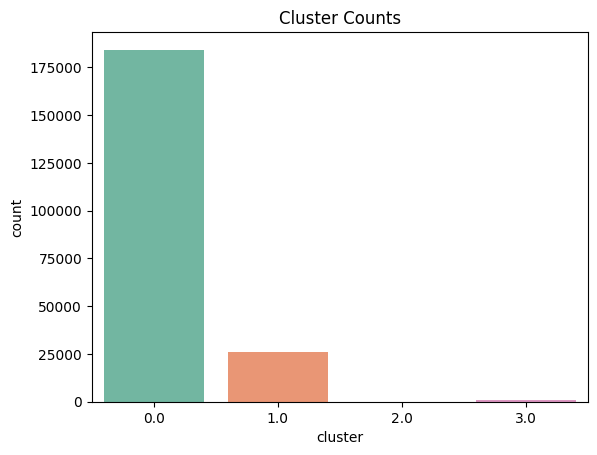

cluster  classification
0.0      Fear              0.280140
         Greed             0.233422
         Extreme Greed     0.203692
         Neutral           0.176796
         Extreme Fear      0.105950
1.0      Fear              0.391535
         Greed             0.250551
         Neutral           0.192324
         Extreme Greed     0.094170
         Extreme Fear      0.071420
2.0      Extreme Greed     0.458333
         Greed             0.187500
         Fear              0.166667
         Neutral           0.145833
         Extreme Fear      0.041667
3.0      Greed             0.727273
         Neutral           0.127096
         Fear              0.097087
         Extreme Fear      0.032657
         Extreme Greed     0.015887
Name: proportion, dtype: float64


In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric features
features = merged_df[['size', 'execution_price', 'start_position']].dropna()

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

merged_df.loc[features.index, 'cluster'] = clusters

# Visualize cluster counts
sns.countplot(data=merged_df.loc[features.index], x='cluster', palette='Set2')
plt.title('Cluster Counts')
plt.show()

# Sentiment distribution per cluster
print(merged_df.groupby('cluster')['classification'].value_counts(normalize=True))


# **7.4.  Sentiment Distribution per Cluster (Stacked Bar)**




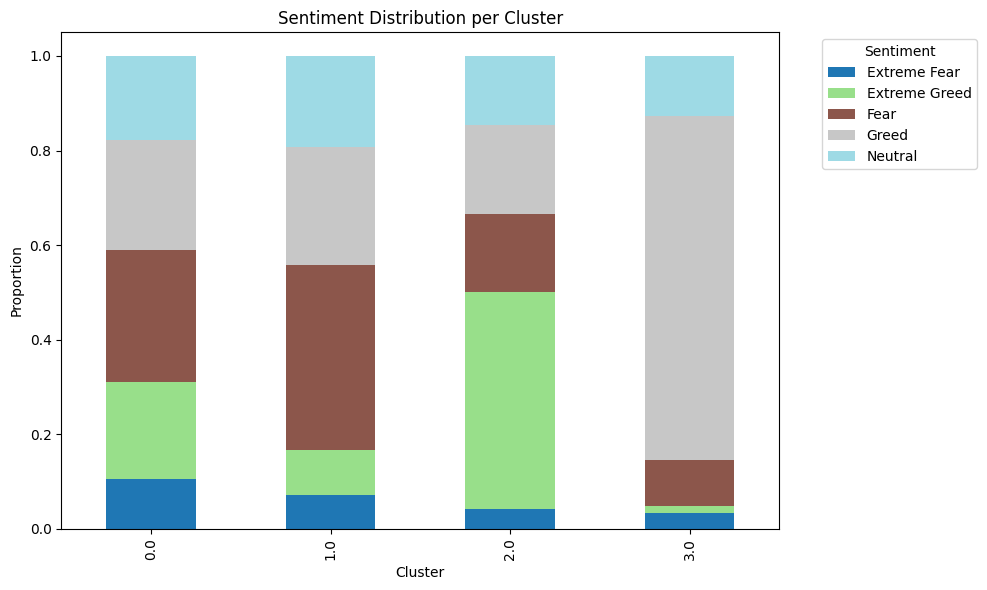

In [91]:
import matplotlib.pyplot as plt
import pandas as pd


cluster_sentiment = merged_df.groupby(['cluster', 'classification']).size().unstack(fill_value=0)
cluster_sentiment_norm = cluster_sentiment.div(cluster_sentiment.sum(axis=1), axis=0)

cluster_sentiment_norm.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title("Sentiment Distribution per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Insights:


*  Clusters 2 and 3 represent traders mostly active in optimistic market conditions (Greed and Extreme Greed), likely taking bigger or more aggressive positions.

*   Clusters 0 and 1 have higher proportions of Fear and Neutral sentiment, which might correspond to more cautious or balanced trading strategies.

*  This clustering suggests that trader behaviors naturally segment into groups
that align with different market moods.


*  Such insights could help design tailored trading strategies or risk controls by recognizing which cluster a trader belongs to, based on their behavior patterns and associated market sentiment.

